In [1]:
import sys
sys.path.append('utils')
sys.path.append('models/Etotmin')
sys.path.append('models')

In [2]:
from cobrak_main_workflows import *
from analysis_functions import *
from plotting_functions import *

from cobrak_main_workflows import run_cobrak_basic
from utils.cobrak_main_workflows import remove_reaction


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from toy_model_full_Wcomp_wo_atp import initialize_model_w_comp
from toy_model_full_WOcomp_wo_atp import initialize_model_wo_comp 


In [5]:
toy_model = initialize_model_w_comp()
toy_model_wo_comp = initialize_model_wo_comp()


## extra parameters

In [6]:
import yeast_params_resp_transporters_cheap_yeast_weights_superhigh_biomassatp as extra_params

In [7]:
objective_target="prot_pool_delivery"
objective_sense=-1

In [ ]:
growth_grid = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
kcat = 1e20
uptake_tol = 0.05

In [ ]:
from collections import defaultdict
import inspect

results_grid1 = defaultdict(dict)

# Get function signature once
sig = inspect.signature(initialize_model_w_comp)
valid_params = set(sig.parameters.keys())

for growth_value in growth_grid:
    try:
        # Build dict of supported parameters from extra_params
        auto_kwargs = {
            name: getattr(extra_params, name)
            for name in dir(extra_params)
            if not name.startswith("_")                 
            and name in valid_params                   
        }

        # Manually override if needed
        auto_kwargs["k_cat_transport"] = kcat
        auto_kwargs["atp_concentration_constraint"] = False
        auto_kwargs["atp_m_concentration_constraint"] = False

        toy_model = initialize_model_w_comp(**auto_kwargs)

        max_glc_uptake = (growth_value,
                          growth_value + uptake_tol * growth_value)

        print("starting cobrak optimization")

        variability_dict_fixed_params = {
            "EX_B": max_glc_uptake
        }

        new_result = run_cobrak_basic(
            toy_model,
            objective_target=objective_target,
            objective_sense=objective_sense,
            variability_dict_fixed_params=variability_dict_fixed_params,
            mode="evo",
            print_result=False,
            pop_size=128
        )

        results_grid1[growth_value] = new_result

    except Exception as e:
        print("ERROR!")
        print(e)

starting cobrak optimization


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.4s remaining:    1.5s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.5s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.7s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.8s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    5.2s
[Parallel(n_jobs=

starting cobrak optimization


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    8.8s remaining:   26.7s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    8.9s remaining:   12.5s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    9.0s remaining:    6.4s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    9.1s remaining:    3.0s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    9.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    5.3s
[Parallel(n_jobs=

starting cobrak optimization


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.3s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.3s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.3s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.3s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.2s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.3s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.3s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.4s remaining:    0.1s
[Pa

starting cobrak optimization


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.3s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.3s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.4s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.4s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.3s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.3s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.3s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.4s remaining:    0.1s
[Pa

INFO: Fewer feasible sampling solutions found than wished.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.17026567459106445s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Batch computation too slow (2.530717372894287s.) Setting batch_size=1.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  50 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done  85 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done 118 out of 128 | elapsed:   10.1s remaining:    0.8s
[Parallel(n_jobs=-1)]: Done 128 out of 128 | elapsed:   10.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Paralle

In [ ]:
from collections import defaultdict
import inspect

results_grid1_w_constraint = defaultdict(dict)

# Inspect function signature once
sig = inspect.signature(initialize_model_w_comp)
valid_params = set(sig.parameters.keys())

for growth_value in growth_grid:

    print(growth_value)
    print(kcat)

    try:
        # Collect supported parameters automatically
        auto_kwargs = {
            name: getattr(extra_params, name)
            for name in dir(extra_params)
            if not name.startswith("_")
            and name in valid_params
        }

        # Manually override specific parameters
        auto_kwargs.update({
            "k_cat_transport": kcat,
            "atp_concentration_constraint": True,
            "atp_m_concentration_constraint": True
        })

        toy_model_w_constraint = initialize_model_w_comp(**auto_kwargs)

        max_glc_uptake = (
            growth_value,
            growth_value + uptake_tol * growth_value
        )

        print("starting cobrak optimization")

        variability_dict_fixed_params = {
            "EX_B": max_glc_uptake
        }

        new_result = run_cobrak_basic(
            toy_model_w_constraint,
            objective_target=objective_target,
            objective_sense=objective_sense,
            variability_dict_fixed_params=variability_dict_fixed_params,
            mode="evo",
            print_result=False,
            pop_size=128
        )

        results_grid1_w_constraint[growth_value] = new_result

    except Exception as e:
        print("ERROR!")
        print(e)

0.05
1e+20
starting cobrak optimization


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.3s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.3s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.5s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.5s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    4.9s
[Parallel(n_jobs=

0.1
1e+20
starting cobrak optimization


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.3s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.5s remaining:    0.8s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.5s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.6s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.15654230117797852s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Batch computation too slow (2.289877414703369s.) Setting batch_size=1.
[Parallel(n_j

0.2
1e+20
starting cobrak optimization


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.5s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.5s remaining:    0.8s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.5s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.5s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.14531564712524414s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Batch computation too slow (3.5297391414642334s.) Setting batch_size=1.
[Parallel(n_

0.5
1e+20
starting cobrak optimization


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.4s remaining:    1.5s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.5s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.5s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.5s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.15292143821716309s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Batch computation too slow (3.891509771347046s.) Setting batch_size=1.
[Parallel(n_j

0.6
1e+20
starting cobrak optimization


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.2s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.4s remaining:    0.6s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.5s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.5s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    5.7s
[Parallel(n_jobs=

In [ ]:
from collections import defaultdict
import inspect

results_grid1_wo = defaultdict(dict)
results_grid1_wo_wo_atpconstraint = defaultdict(dict)


# Inspect signature once
sig_wo = inspect.signature(initialize_model_wo_comp)
valid_params_wo = set(sig_wo.parameters.keys())


# =========================================================
# CASE 1: ATP constraint ON
# =========================================================
for growth_value in growth_grid:

    print(growth_value)
    print(kcat)

    try:
        auto_kwargs = {
            name: getattr(extra_params, name)
            for name in dir(extra_params)
            if not name.startswith("_")
            and name in valid_params_wo
        }

        # Explicit overrides (keep these deterministic)
        auto_kwargs.update({

            "atp_concentration_constraint": True
        })

        toy_model_wo = initialize_model_wo_comp(**auto_kwargs)

        max_glc_uptake = (
            growth_value,
            growth_value + uptake_tol * growth_value
        )

        print("starting cobrak optimization")

        new_result = run_cobrak_basic(
            toy_model_wo,
            objective_target=objective_target,
            objective_sense=objective_sense,
            variability_dict_fixed_params={"EX_B": max_glc_uptake},
            mode="evo",
            print_result=False,
            pop_size=128
        )

        results_grid1_wo[growth_value] = new_result

    except Exception as e:
        print("ERROR!")
        print(e)


# =========================================================
# CASE 2: ATP constraint OFF
# =========================================================
for growth_value in growth_grid:

    print(growth_value)
    print(kcat)

    try:
        auto_kwargs = {
            name: getattr(extra_params, name)
            for name in dir(extra_params)
            if not name.startswith("_")
            and name in valid_params_wo
        }

        auto_kwargs.update({

            "atp_concentration_constraint": False
        })

        toy_model_wo_wo_atpconstraint = initialize_model_wo_comp(**auto_kwargs)

        max_glc_uptake = (
            growth_value,
            growth_value + uptake_tol * growth_value
        )

        print("starting cobrak optimization")

        new_result = run_cobrak_basic(
            toy_model_wo_wo_atpconstraint,
            objective_target=objective_target,
            objective_sense=objective_sense,
            variability_dict_fixed_params={"EX_B": max_glc_uptake},
            mode="evo",
            print_result=False,
            pop_size=128
        )

        results_grid1_wo_wo_atpconstraint[growth_value] = new_result

    except Exception as e:
        print("ERROR!")
        print(e)

0.05
1e+20
starting cobrak optimization


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.3s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.3s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.5s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.5s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.15824604034423828s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Batch computation too 

0.1
1e+20
starting cobrak optimization


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.3s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.3s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.3s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.3s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1380610466003418s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Batch computation too slow (2.660640001296997s.) Setting batch_size=1.
[Parallel(n_jo

0.2
1e+20
starting cobrak optimization


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.3s remaining:    1.2s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.3s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.4s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.5s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.17792081832885742s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Batch computation too slow (2.7137093544006348s.) Setting batch_size=1.
[Parallel(n_

0.5
1e+20
starting cobrak optimization


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.3s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.3s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.3s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.5s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1290740966796875s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Batch computation too slow (2.787646532058716s.) Setting batch_size=1.
[Parallel(n_jo

0.6
1e+20
starting cobrak optimization


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.3s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.3s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.4s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.4s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.14368629455566406s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Batch computation too 

In [12]:
df = pd.DataFrame.from_dict(results_grid1, orient='index')
df.index.name = 'growth'
df.reset_index(inplace=True)

df_wo = pd.DataFrame.from_dict(results_grid1_wo, orient='index')
df_wo.index.name = 'growth'
df_wo.reset_index(inplace=True)

df_wo_wo_atpconstraint = pd.DataFrame.from_dict(results_grid1_wo_wo_atpconstraint, orient='index')
df_wo_wo_atpconstraint.index.name = 'growth'
df_wo_wo_atpconstraint.reset_index(inplace=True)

df_w_atpconstraint = pd.DataFrame.from_dict(results_grid1_w_constraint, orient='index')
df_w_atpconstraint.index.name = 'growth'
df_w_atpconstraint.reset_index(inplace=True)


In [13]:
model_enzyme_weights = toy_model.enzymes

groups = {
    "Transporters": ["ATP_transporter", "ADP_transporter", 
                     "M_transporter", "C_transporter"],
    "Respiration": ["E_resp"],
    "Glycolysis": ["E_glyc"],
    "Biomass": ["Biomass_enz"]
}


In [14]:
df = append_analysis_rows(df, model_enzyme_weights, groups=groups)
df["ATP conc., c"] = np.exp(df["x_ATP"])
df["ATP conc., m"] = np.exp(df["x_ATP_m"])
df["ADP conc., c"] = np.exp(df["x_ADP"])
df["ADP conc., m"] = np.exp(df["x_ADP_m"])
df["ATP/ADP, c"] = df["ATP conc., c"] / df["ADP conc., c"]
df["ATP/ADP, m"] = df["ATP conc., m"] / df["ADP conc., m"]



df_w_atpconstraint = append_analysis_rows(df_w_atpconstraint, model_enzyme_weights, groups=groups)
df_w_atpconstraint["ATP conc., c"] = np.exp(df_w_atpconstraint["x_ATP"])
df_w_atpconstraint["ATP conc., m"] = np.exp(df_w_atpconstraint["x_ATP_m"])
df_w_atpconstraint["ADP conc., c"] = np.exp(df_w_atpconstraint["x_ADP"])
df_w_atpconstraint["ADP conc., m"] = np.exp(df_w_atpconstraint["x_ADP_m"])
df_w_atpconstraint["ATP/ADP, c"] = df_w_atpconstraint["ATP conc., c"] / df_w_atpconstraint["ADP conc., c"]
df_w_atpconstraint["ATP/ADP, m"] = df_w_atpconstraint["ATP conc., m"] / df_w_atpconstraint["ADP conc., m"]



df_wo = append_analysis_rows(df_wo, model_enzyme_weights, groups=groups)

df_wo["ATP conc."] = np.exp(df_wo["x_ATP"])
df_wo["ADP conc."] = np.exp(df_wo["x_ADP"])
df_wo["ATP/ADP"] = df_wo["ATP conc."] / df_wo["ADP conc."]


df_wo_wo_atpconstraint = append_analysis_rows(df_wo_wo_atpconstraint, model_enzyme_weights, groups=groups)

df_wo_wo_atpconstraint["ATP conc."] = np.exp(df_wo_wo_atpconstraint["x_ATP"])
df_wo_wo_atpconstraint["ADP conc."] = np.exp(df_wo_wo_atpconstraint["x_ADP"])
df_wo_wo_atpconstraint["ATP/ADP"] = df_wo_wo_atpconstraint["ATP conc."] / df_wo_wo_atpconstraint["ADP conc."]


# Comparison of Versions

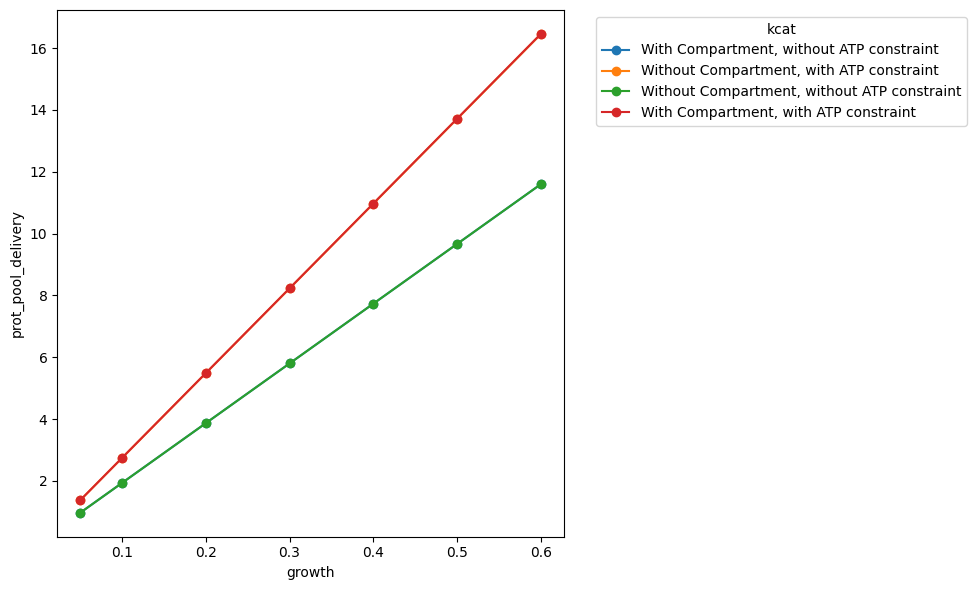

In [15]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values(['growth'])
df_wo_sorted = df_wo.sort_values(['growth'])
df_wo_wo_atpconstraint_sorted = df_wo_wo_atpconstraint.sort_values(['growth'])
df_w_atpconstraint_sorted = df_w_atpconstraint.sort_values(['growth'])


plt.figure(figsize=(10, 6))

plt.plot(
    df_sorted['growth'],
    df_sorted['prot_pool_delivery'],
    marker='o',        # <-- points
    linestyle='-',     # <-- line
    label=f'With Compartment, without ATP constraint'
)

plt.plot(
    df_wo_sorted['growth'],
    df_wo_sorted['prot_pool_delivery'],
    marker='o',        # <-- points
    linestyle='-',     # <-- line
    label=f'Without Compartment, with ATP constraint'
)

plt.plot(
    df_wo_wo_atpconstraint_sorted['growth'],
    df_wo_wo_atpconstraint_sorted['prot_pool_delivery'],
    marker='o',        # <-- points
    linestyle='-',     # <-- line
    label=f'Without Compartment, without ATP constraint'
)


plt.plot(
    df_w_atpconstraint_sorted['growth'],
    df_w_atpconstraint_sorted['prot_pool_delivery'],
    marker='o',        # <-- points
    linestyle='-',     # <-- line
    label=f'With Compartment, with ATP constraint'
)


plt.xlabel('growth')
plt.ylabel('prot_pool_delivery')
plt.legend(title='kcat', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

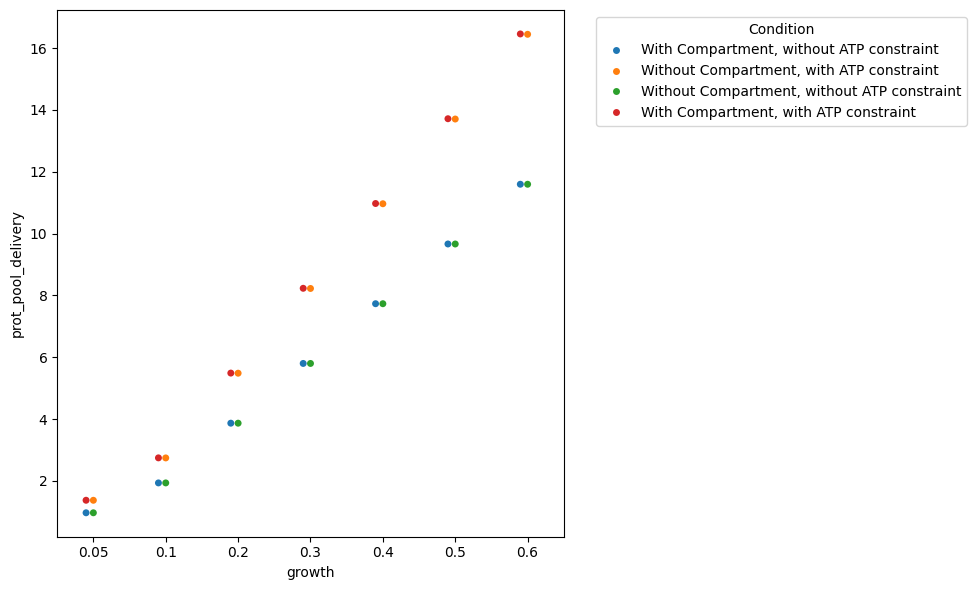

In [22]:
import pandas as pd

df_sorted["condition"] = "With Compartment, without ATP constraint"
df_wo_sorted["condition"] = "Without Compartment, with ATP constraint"
df_wo_wo_atpconstraint_sorted["condition"] = "Without Compartment, without ATP constraint"
df_w_atpconstraint_sorted["condition"] = "With Compartment, with ATP constraint"

df_all = pd.concat([
    df_sorted,
    df_wo_sorted,
    df_wo_wo_atpconstraint_sorted,
    df_w_atpconstraint_sorted
])


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.swarmplot(
    data=df_all,
    x="growth",
    y="prot_pool_delivery",
    hue="condition"
)

plt.xlabel("growth")
plt.ylabel("prot_pool_delivery")
plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# All plots: 
## 1)Enzyme mass composition for version with compartment and constraint


In [16]:
columns_to_plot = [
    'Glycolysis', 'Respiration',
    'Transport_M', 'Transport_C',
    'Transport_ATP', 'Transport_ADP',
    'EX_S', 'EX_C', 'EX_P', 'EX_B',
    'Biomass_Rea'
]

groups = {
    "Transport": [],
    "EX": [],
    "Other": []
}

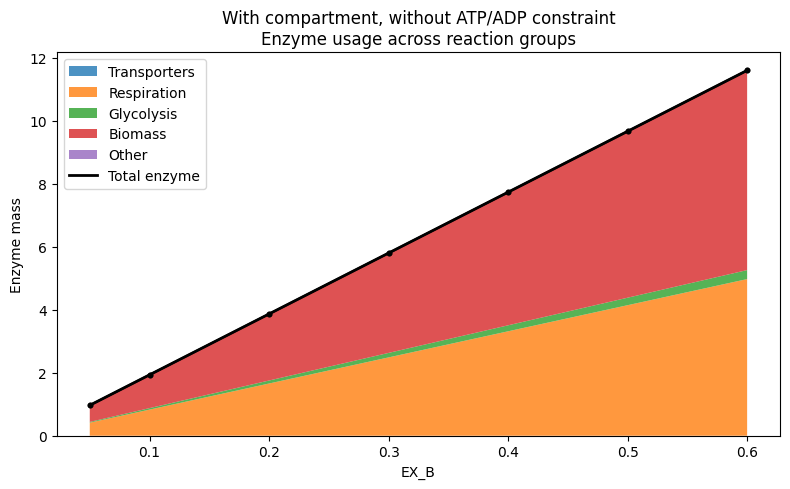

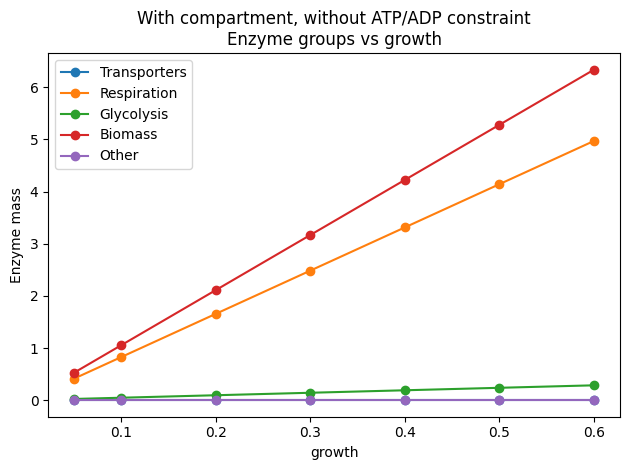

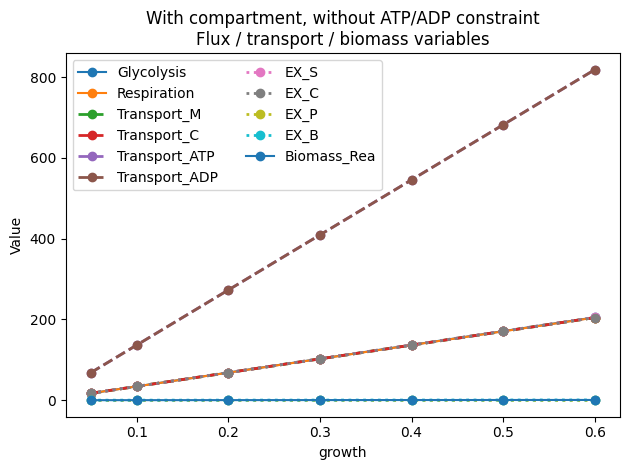

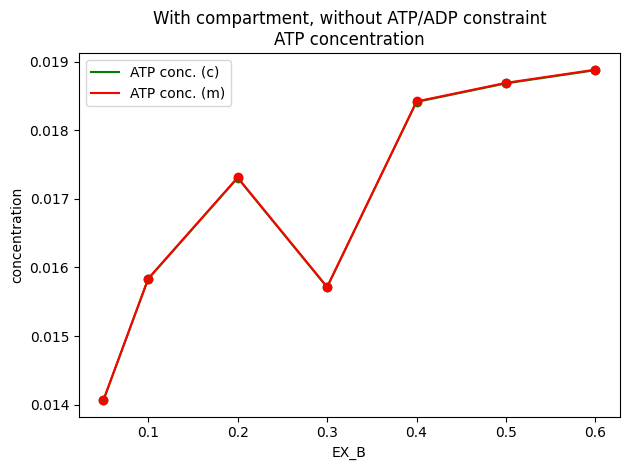

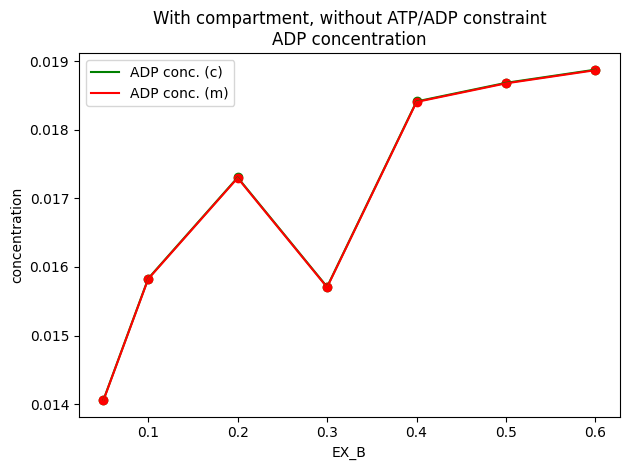

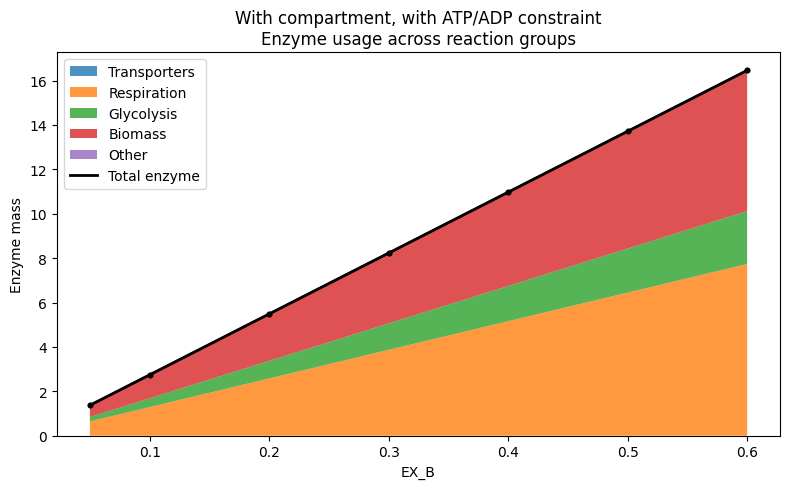

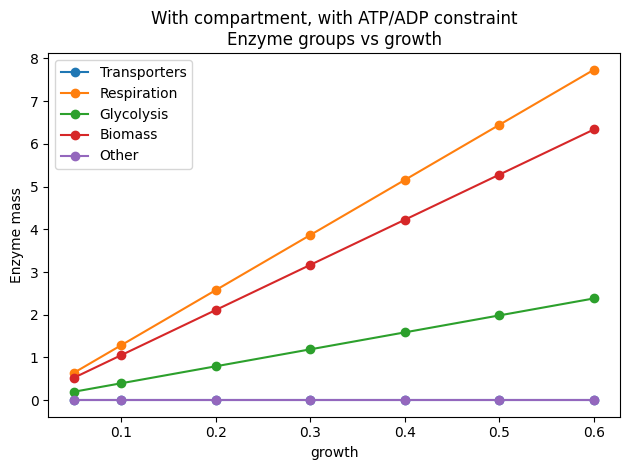

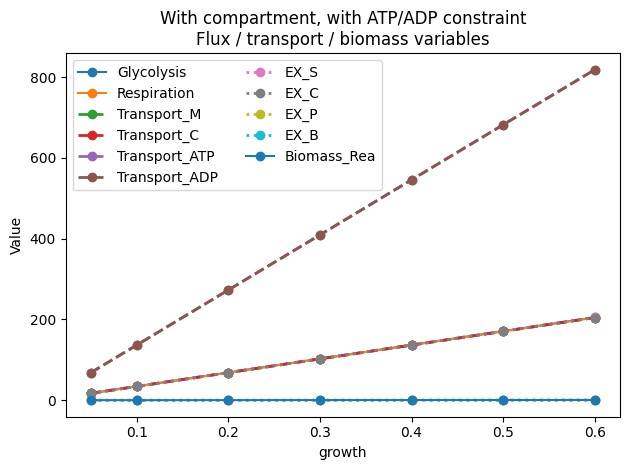

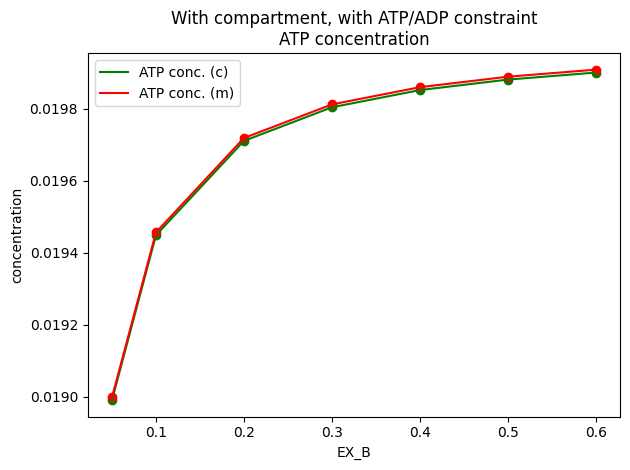

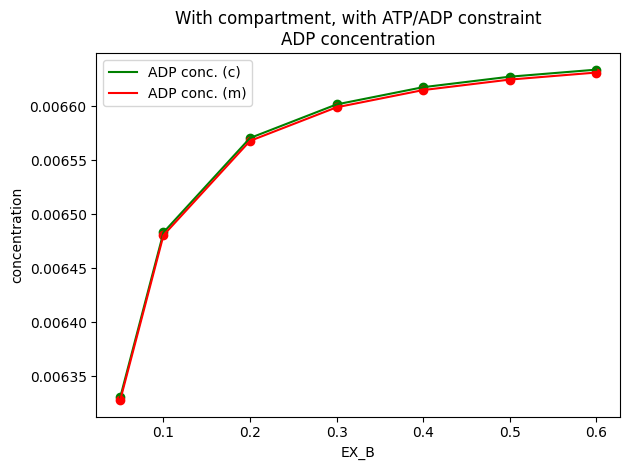

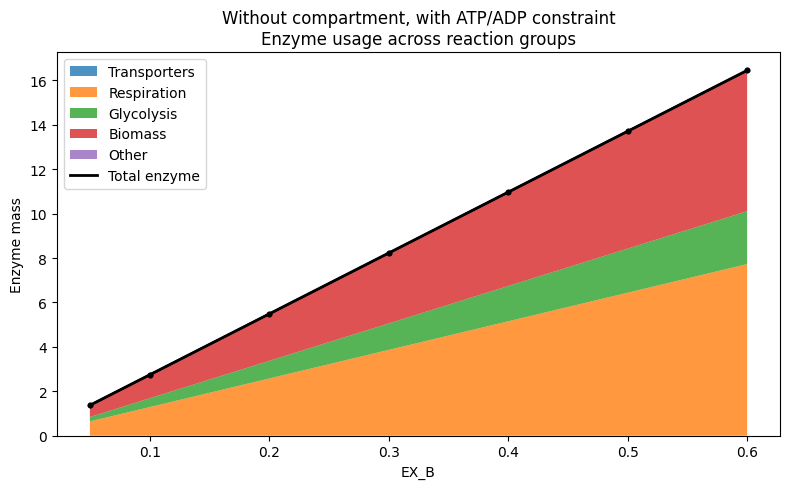

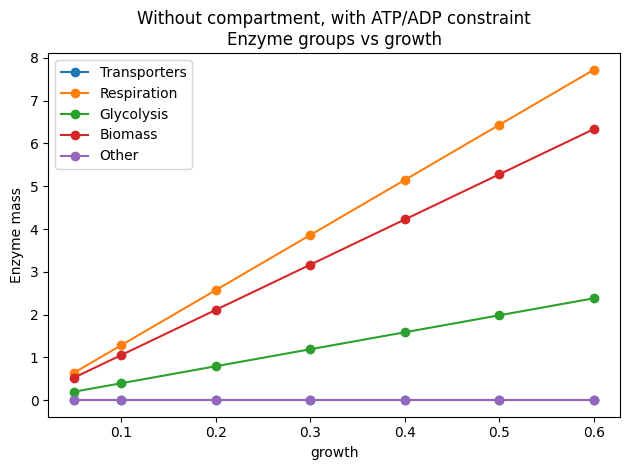

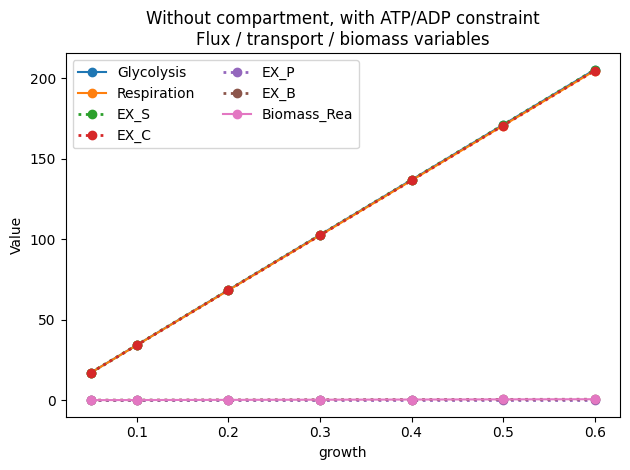

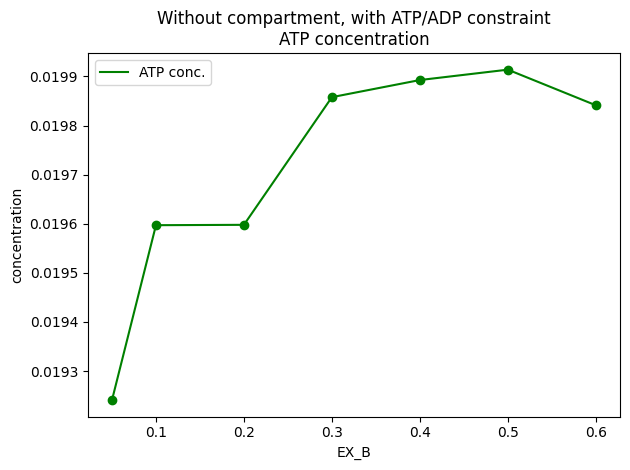

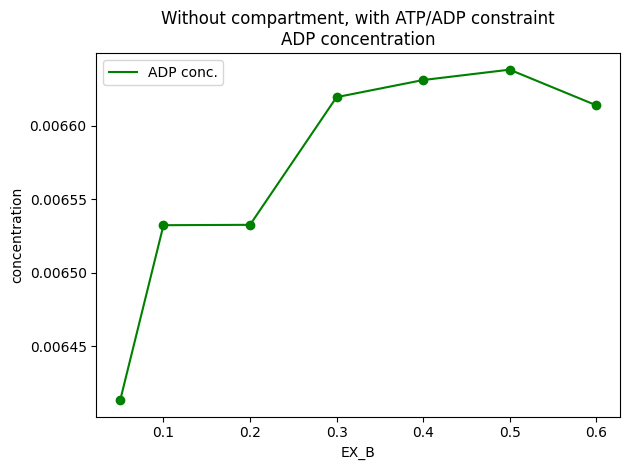

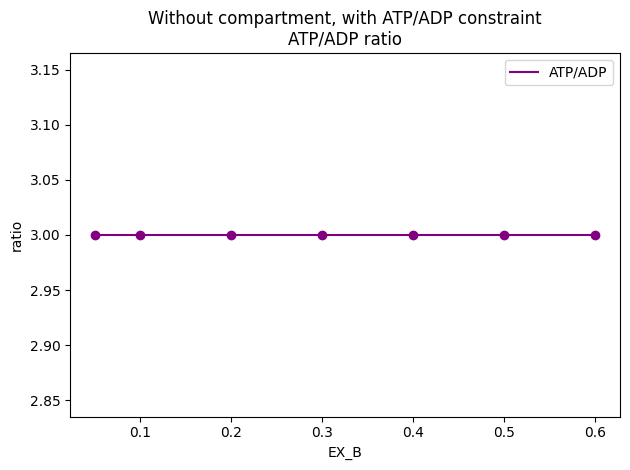

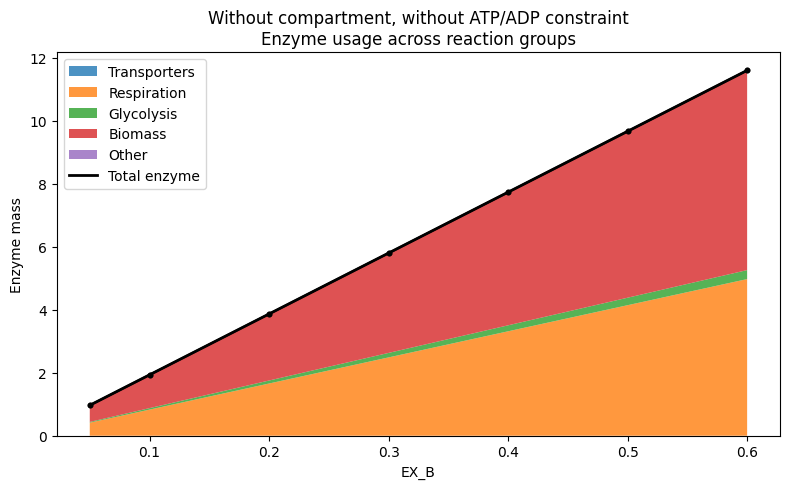

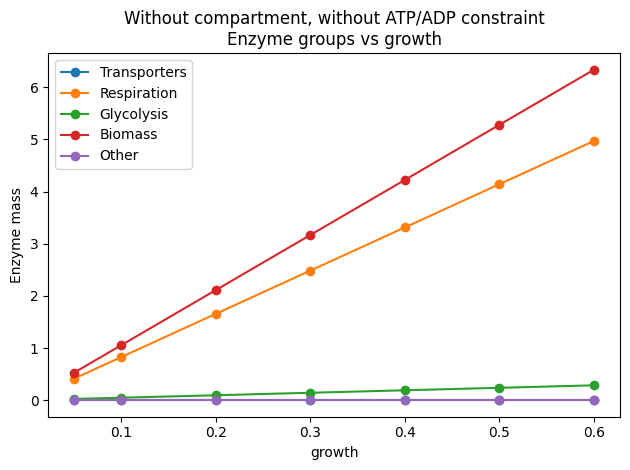

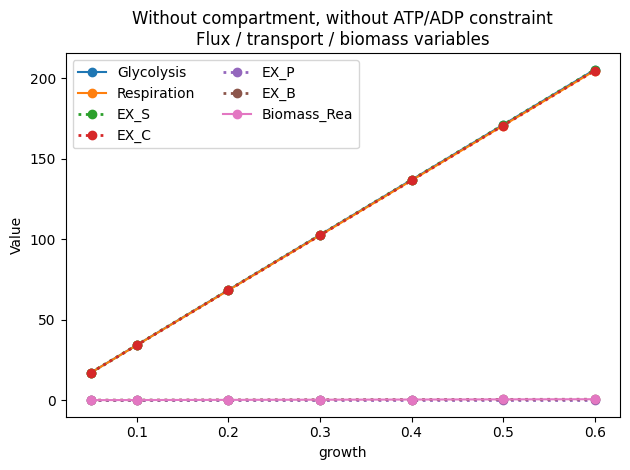

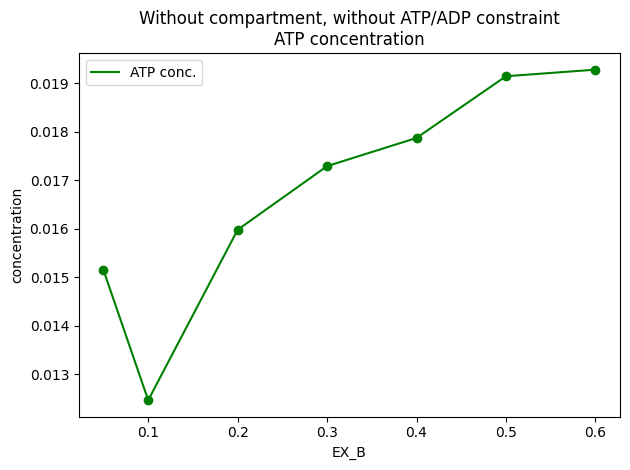

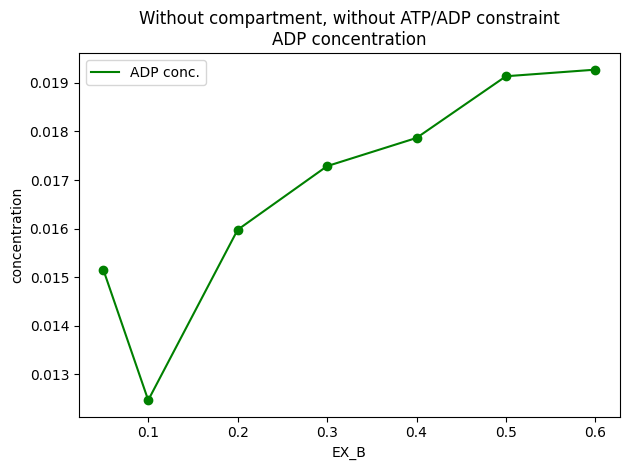

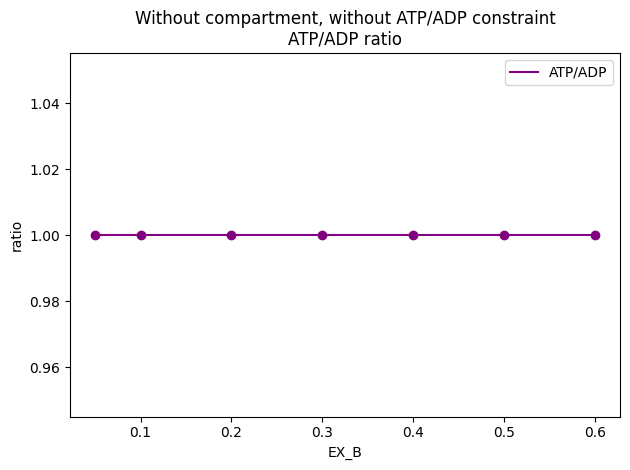

In [17]:
plot_enzyme_analysis(df, supertitle="With compartment, without ATP/ADP constraint")
plot_enzyme_analysis(df_w_atpconstraint, supertitle="With compartment, with ATP/ADP constraint")
plot_enzyme_analysis(df_wo, supertitle="Without compartment, with ATP/ADP constraint")
plot_enzyme_analysis(df_wo_wo_atpconstraint, supertitle="Without compartment, without ATP/ADP constraint")

In [18]:
df_wo.columns

Index(['growth', 'Glycolysis', 'Respiration', 'EX_S', 'EX_C', 'EX_P', 'EX_B',
       'Biomass_Rea', 'prot_pool_delivery', 'enzyme_E_glyc_of_Glycolysis',
       'enzyme_E_resp_of_Respiration', 'enzyme_Biomass_enz_of_Biomass_Rea',
       'x_S', 'x_M', 'x_C', 'x_ATP', 'x_ADP', 'x_B', 'var_B', 'dG0_Glycolysis',
       'f_var_Glycolysis', 'kappa_substrates_Glycolysis',
       'kappa_products_Glycolysis', 'kappa_var_Glycolysis',
       'gamma_var_Glycolysis', 'dG0_Respiration', 'f_var_Respiration',
       'kappa_substrates_Respiration', 'kappa_products_Respiration',
       'kappa_var_Respiration', 'gamma_var_Respiration', 'dG0_Biomass_Rea',
       'f_var_Biomass_Rea', 'gamma_var_Biomass_Rea', 'OBJECTIVE_VAR',
       'SOLVER_STATUS', 'TERMINATION_CONDITION', 'ALL_OK',
       'total_enzyme_weight', 'total_mass', 'group_totals', 'enzyme_totals',
       'ATP conc.', 'ADP conc.', 'ATP/ADP'],
      dtype='object')

In [19]:
df_wo.x_ATP

0   -3.950731
1   -3.932377
2   -3.932340
3   -3.919160
4   -3.917406
5   -3.916344
6   -3.919991
Name: x_ATP, dtype: float64

In [20]:
df_wo['ATP conc.']

0    0.019241
1    0.019597
2    0.019598
3    0.019858
4    0.019893
5    0.019914
6    0.019841
Name: ATP conc., dtype: float64

In [21]:
df_wo['ATP/ADP']

0    3.0
1    3.0
2    3.0
3    3.0
4    3.0
5    3.0
6    3.0
Name: ATP/ADP, dtype: float64